In [5]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(42)
random.seed(42)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [6]:
n_registros = 900

tipos_equipamento = ['Trator', 'Colheitadeira', 'Pulverizador', 'Plantadeira', 'Semeadora']
regioes = ['Sul', 'Sudeste', 'Centro-Oeste', 'Nordeste', 'Norte']
tipos_operacao = ['Campo aberto', 'Transporte', 'Proximidade de água', 'Encosta', 'Armazenamento']
condicoes_climaticas = ['Seco', 'Chuvoso', 'Tempestade', 'Neblina', 'Normal']

dados = {
    'id_equipamento': [f'EQP-{1000+i}' for i in range(n_registros)],
    'tipo_equipamento': np.random.choice(tipos_equipamento, n_registros),
    'regiao': np.random.choice(regioes, n_registros),
    'tipo_operacao': np.random.choice(tipos_operacao, n_registros,
                                       p=[0.35, 0.20, 0.15, 0.15, 0.15]),
    'condicao_climatica': np.random.choice(condicoes_climaticas, n_registros,
                                            p=[0.30, 0.25, 0.10, 0.10, 0.25]),
    'temperatura': np.round(np.random.uniform(15, 40, n_registros), 1),
    'umidade': np.round(np.random.uniform(20, 95, n_registros), 1),
    'tempo_uso_anos': np.random.randint(1, 20, n_registros),
    'historico_incidentes': np.random.choice([0, 1, 2, 3, 4, 5],
                                              n_registros,
                                              p=[0.45, 0.25, 0.15, 0.08, 0.05, 0.02])
}


data_base = datetime(2024, 4, 29)
dados['data_operacao'] = [data_base + timedelta(days=int(np.random.randint(0, 730)))
                           for _ in range(n_registros)]


df = pd.DataFrame(dados)

indices_nulos_clima = np.random.choice(df.index, size=60, replace=False)
df.loc[indices_nulos_clima, 'condicao_climatica'] = np.nan

indices_nulos_umidade = np.random.choice(df.index, size=45, replace=False)
df.loc[indices_nulos_umidade, 'umidade'] = np.nan

indices_inconsistentes = np.random.choice(df.index, size=75, replace=False)
df.loc[indices_inconsistentes[:30], 'tipo_equipamento'] = 'trator '
df.loc[indices_inconsistentes[30:54], 'tipo_equipamento'] = 'COLHEITADEIRA'
df.loc[indices_inconsistentes[54:], 'regiao'] = ' sul'

indices_data_string = np.random.choice(df.index, size=90, replace=False)
df.loc[indices_data_string, 'data_operacao'] = df.loc[indices_data_string,
                                                       'data_operacao'].astype(str)

indices_outliers = np.random.choice(df.index, size=12, replace=False)
df.loc[indices_outliers[:6], 'temperatura'] = np.round(np.random.uniform(50, 60, 6), 1)
df.loc[indices_outliers[6:], 'umidade'] = np.round(np.random.uniform(110, 150, 6), 1)

print(f"Dataset gerado com {len(df)} registros e {len(df.columns)} colunas.")
df.head()

Dataset gerado com 900 registros e 10 colunas.


,id_equipamento,tipo_equipamento,regiao,tipo_operacao,condicao_climatica,temperatura,umidade,tempo_uso_anos,historico_incidentes,data_operacao
0,EQP-1000,Plantadeira,Centro-Oeste,Proximidade de água,Seco,28.5,78.9,14,0,2025-02-14
1,EQP-1001,Semeadora,Sul,Proximidade de água,Neblina,23.6,NaN,14,0,2025-07-25
2,EQP-1002,Pulverizador,Norte,Transporte,Seco,25.4,65.4,10,2,2026-04-13
3,EQP-1003,COLHEITADEIRA,Nordeste,Transporte,Neblina,33.3,43.1,12,1,2024-05-22
4,EQP-1004,Semeadora,Nordeste,Proximidade de água,Normal,37.0,82.8,6,0,2025-03-05


In [7]:
print("=" * 60)
print("INFORMAÇÕES GERAIS DO DATASET")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("ESTATÍSTICAS DESCRITIVAS (colunas numéricas)")
print("=" * 60)
print(df.describe())

print("\n" + "=" * 60)
print("VALORES NULOS POR COLUNA")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print("CATEGORIAS ÚNICAS NAS COLUNAS DE TEXTO")
print("=" * 60)
for coluna in ['tipo_equipamento', 'regiao', 'tipo_operacao', 'condicao_climatica']:
    print(f"\n{coluna}:")
    print(df[coluna].unique())

INFORMAÇÕES GERAIS DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_equipamento        900 non-null    object        
 1   tipo_equipamento      900 non-null    object        
 2   regiao                900 non-null    object        
 3   tipo_operacao         900 non-null    object        
 4   condicao_climatica    840 non-null    object        
 5   temperatura           900 non-null    float64       
 6   umidade               855 non-null    float64       
 7   tempo_uso_anos        900 non-null    int64         
 8   historico_incidentes  900 non-null    int64         
 9   data_operacao         900 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 70.4+ KB

ESTATÍSTICAS DESCRITIVAS (colunas numéricas)
       temperatura     umidade  tempo_uso

In [8]:
df['tipo_equipamento'] = df['tipo_equipamento'].str.strip().str.title()
df['regiao'] = df['regiao'].str.strip().str.title()

mediana_umidade = df['umidade'].median()
df['umidade'] = df['umidade'].fillna(mediana_umidade)

moda_clima = df['condicao_climatica'].mode()[0]
df['condicao_climatica'] = df['condicao_climatica'].fillna(moda_clima)

df['data_operacao'] = pd.to_datetime(df['data_operacao'])

print("=" * 60)
print("APÓS A LIMPEZA")
print("=" * 60)

print("\nValores nulos restantes:")
print(df.isnull().sum())

print(f"\nMediana usada para preencher umidade: {mediana_umidade}")
print(f"Moda usada para preencher condicao_climatica: '{moda_clima}'")

print("\nCategorias únicas após padronização:")
for coluna in ['tipo_equipamento', 'regiao', 'condicao_climatica']:
    print(f"\n{coluna}:")
    print(df[coluna].unique())

APÓS A LIMPEZA

Valores nulos restantes:
id_equipamento          0
tipo_equipamento        0
regiao                  0
tipo_operacao           0
condicao_climatica      0
temperatura             0
umidade                 0
tempo_uso_anos          0
historico_incidentes    0
data_operacao           0
dtype: int64

Mediana usada para preencher umidade: 57.4
Moda usada para preencher condicao_climatica: 'Seco'

Categorias únicas após padronização:

tipo_equipamento:
['Plantadeira' 'Semeadora' 'Pulverizador' 'Colheitadeira' 'Trator']

regiao:
['Centro-Oeste' 'Sul' 'Norte' 'Nordeste' 'Sudeste']

condicao_climatica:
['Seco' 'Neblina' 'Normal' 'Tempestade' 'Chuvoso']


In [9]:
mapa_risco_operacional = {
    'Armazenamento': 1,
    'Campo aberto': 2,
    'Transporte': 3,
    'Encosta': 4,
    'Proximidade de água': 5
}
df['risco_operacional'] = df['tipo_operacao'].map(mapa_risco_operacional)

mapa_risco_ambiental = {
    'Normal': 1,
    'Seco': 2,
    'Neblina': 3,
    'Chuvoso': 4,
    'Tempestade': 5
}
df['risco_ambiental'] = df['condicao_climatica'].map(mapa_risco_ambiental)

def classificar_idade(anos):
    if anos <= 5:
        return 1
    elif anos <= 10:
        return 2
    elif anos <= 15:
        return 3
    else:
        return 4

df['risco_idade'] = df['tempo_uso_anos'].apply(classificar_idade)

def classificar_incidentes(qtd):
    if qtd == 0:
        return 1
    elif qtd <= 2:
        return 3
    else:
        return 5

df['risco_historico'] = df['historico_incidentes'].apply(classificar_incidentes)

df['zona_critica'] = (
    (df['tipo_operacao'] == 'Proximidade de água') |
    (df['condicao_climatica'] == 'Tempestade') |
    (df['historico_incidentes'] >= 3)
)

print("=" * 60)
print("NOVAS VARIÁVEIS CRIADAS")
print("=" * 60)
print(df[['tipo_operacao', 'risco_operacional',
         'condicao_climatica', 'risco_ambiental',
         'tempo_uso_anos', 'risco_idade',
         'historico_incidentes', 'risco_historico',
         'zona_critica']].head(10))

print(f"\nTotal de equipamentos em zona crítica: {df['zona_critica'].sum()}")

NOVAS VARIÁVEIS CRIADAS
         tipo_operacao  risco_operacional condicao_climatica  risco_ambiental  tempo_uso_anos  risco_idade  historico_incidentes  risco_historico  zona_critica
0  Proximidade de água                  5               Seco                2              14            3                     0                1          True
1  Proximidade de água                  5            Neblina                3              14            3                     0                1          True
2           Transporte                  3               Seco                2              10            2                     2                3         False
3           Transporte                  3            Neblina                3              12            3                     1                3         False
4  Proximidade de água                  5             Normal                1               6            2                     0                1          True
5         Campo 

In [10]:
peso_operacional = 0.25
peso_ambiental = 0.20
peso_idade = 0.15
peso_historico = 0.40

df['score_risco'] = (
    (df['risco_operacional'] / 5) * peso_operacional * 100 +
    (df['risco_ambiental'] / 5) * peso_ambiental * 100 +
    (df['risco_idade'] / 4) * peso_idade * 100 +
    (df['risco_historico'] / 5) * peso_historico * 100
)

df['score_risco'] = df['score_risco'].round(2)

# Conferindo os resultados
print("=" * 60)
print("SCORE DE RISCO CALCULADO")
print("=" * 60)

print("\nEstatísticas do score:")
print(df['score_risco'].describe())

print("\nTop 10 equipamentos com maior score de risco:")
print(df[['id_equipamento', 'tipo_equipamento', 'regiao',
         'tipo_operacao', 'condicao_climatica',
         'historico_incidentes', 'score_risco']]
      .sort_values('score_risco', ascending=False)
      .head(10))

print("\nTop 5 equipamentos com menor score de risco:")
print(df[['id_equipamento', 'tipo_equipamento', 'regiao',
         'tipo_operacao', 'score_risco']]
      .sort_values('score_risco', ascending=True)
      .head(5))

SCORE DE RISCO CALCULADO

Estatísticas do score:
count    900.000000
mean      52.916667
std       14.777498
min       20.750000
25%       41.750000
50%       51.500000
75%       62.562500
max      100.000000
Name: score_risco, dtype: float64

Top 10 equipamentos com maior score de risco:
    id_equipamento tipo_equipamento        regiao        tipo_operacao condicao_climatica  historico_incidentes  score_risco
25        EQP-1025     Pulverizador  Centro-Oeste  Proximidade de água         Tempestade                     5       100.00
290       EQP-1290    Colheitadeira         Norte  Proximidade de água            Chuvoso                     4        96.00
724       EQP-1724           Trator           Sul  Proximidade de água         Tempestade                     3        92.50
177       EQP-1177           Trator         Norte  Proximidade de água            Chuvoso                     3        92.25
260       EQP-1260    Colheitadeira           Sul  Proximidade de água            Neb

In [11]:
def classificar_risco(score):
    if score < 40:
        return 'Baixo'
    elif score < 65:
        return 'Médio'
    else:
        return 'Alto'

df['classificacao_risco'] = df['score_risco'].apply(classificar_risco)

print("=" * 60)
print("CLASSIFICAÇÃO DE RISCO")
print("=" * 60)

print("\nQuantidade de equipamentos por classificação:")
print(df['classificacao_risco'].value_counts())

print("\nPercentual por classificação:")
print((df['classificacao_risco'].value_counts(normalize=True) * 100).round(2))

print("\nExemplos de cada categoria:")
for nivel in ['Alto', 'Médio', 'Baixo']:
    print(f"\n--- {nivel} ---")
    exemplo = df[df['classificacao_risco'] == nivel].head(3)
    print(exemplo[['id_equipamento', 'tipo_operacao',
                  'condicao_climatica', 'score_risco',
                  'classificacao_risco']])

CLASSIFICAÇÃO DE RISCO

Quantidade de equipamentos por classificação:
classificacao_risco
Médio    537
Alto     199
Baixo    164
Name: count, dtype: int64

Percentual por classificação:
classificacao_risco
Médio    59.67
Alto     22.11
Baixo    18.22
Name: proportion, dtype: float64

Exemplos de cada categoria:

--- Alto ---
   id_equipamento        tipo_operacao condicao_climatica  score_risco classificacao_risco
8        EQP-1008  Proximidade de água            Neblina        84.50                Alto
10       EQP-1010           Transporte               Seco        78.00                Alto
17       EQP-1017              Encosta         Tempestade        67.75                Alto

--- Médio ---
  id_equipamento        tipo_operacao condicao_climatica  score_risco classificacao_risco
0       EQP-1000  Proximidade de água               Seco        52.25               Médio
1       EQP-1001  Proximidade de água            Neblina        56.25               Médio
2       EQP-1002        

In [12]:
def gerar_alertas(linha):
    alertas = []


    if linha['tipo_operacao'] == 'Proximidade de água':
        alertas.append('Risco elevado por operação próxima à água')


    if linha['condicao_climatica'] in ['Tempestade', 'Chuvoso']:
        alertas.append(f"Condição climática adversa: {linha['condicao_climatica']}")


    if linha['historico_incidentes'] >= 3:
        alertas.append(f"Histórico crítico: {linha['historico_incidentes']} incidentes")


    if linha['tempo_uso_anos'] >= 15:
        alertas.append(f"Equipamento com {linha['tempo_uso_anos']} anos de uso")


    if linha['classificacao_risco'] == 'Alto':
        alertas.append('Classificação geral: ALTO RISCO')

    return alertas

df['alertas'] = df.apply(gerar_alertas, axis=1)

df['qtd_alertas'] = df['alertas'].apply(len)

# Conferindo o resultado
print("=" * 60)
print("SISTEMA DE ALERTAS")
print("=" * 60)

print(f"\nTotal de equipamentos com pelo menos 1 alerta: "
      f"{(df['qtd_alertas'] > 0).sum()}")

print("\nDistribuição da quantidade de alertas:")
print(df['qtd_alertas'].value_counts().sort_index())

print("\nTop 10 equipamentos com mais alertas:")
top_alertas = df.sort_values('qtd_alertas', ascending=False).head(10)
for _, linha in top_alertas.iterrows():
    print(f"\n{linha['id_equipamento']} - {linha['tipo_equipamento']} "
          f"({linha['regiao']}) - Score: {linha['score_risco']}")
    for alerta in linha['alertas']:
        print(f"   - {alerta}")

SISTEMA DE ALERTAS

Total de equipamentos com pelo menos 1 alerta: 590

Distribuição da quantidade de alertas:
qtd_alertas
0    310
1    331
2    120
3    112
4     25
5      2
Name: count, dtype: int64

Top 10 equipamentos com mais alertas:

EQP-1290 - Colheitadeira (Norte) - Score: 96.0
   - Risco elevado por operação próxima à água
   - Condição climática adversa: Chuvoso
   - Histórico crítico: 4 incidentes
   - Equipamento com 17 anos de uso
   - Classificação geral: ALTO RISCO

EQP-1025 - Pulverizador (Centro-Oeste) - Score: 100.0
   - Risco elevado por operação próxima à água
   - Condição climática adversa: Tempestade
   - Histórico crítico: 5 incidentes
   - Equipamento com 19 anos de uso
   - Classificação geral: ALTO RISCO

EQP-1064 - Colheitadeira (Centro-Oeste) - Score: 88.0
   - Risco elevado por operação próxima à água
   - Histórico crítico: 3 incidentes
   - Equipamento com 18 anos de uso
   - Classificação geral: ALTO RISCO

EQP-1619 - Plantadeira (Norte) - Score: 80.

In [13]:
def relatorio_top_equipamentos(n=10):
    """Lista os N equipamentos com maior score de risco."""
    print("=" * 60)
    print(f"TOP {n} EQUIPAMENTOS COM MAIOR RISCO")
    print("=" * 60)
    top = df.sort_values('score_risco', ascending=False).head(n)
    print(top[['id_equipamento', 'tipo_equipamento', 'regiao',
              'tipo_operacao', 'score_risco',
              'classificacao_risco']].to_string(index=False))


def relatorio_risco_por_regiao():
    """Mostra o risco médio agrupado por região."""
    print("=" * 60)
    print("RANKING DE RISCO POR REGIÃO")
    print("=" * 60)
    ranking = df.groupby('regiao').agg(
        score_medio=('score_risco', 'mean'),
        qtd_equipamentos=('id_equipamento', 'count'),
        qtd_alto_risco=('classificacao_risco',
                       lambda x: (x == 'Alto').sum())
    ).round(2).sort_values('score_medio', ascending=False)
    print(ranking)


def relatorio_risco_por_operacao():
    """Mostra o risco médio agrupado por tipo de operação."""
    print("=" * 60)
    print("RANKING DE RISCO POR TIPO DE OPERAÇÃO")
    print("=" * 60)
    ranking = df.groupby('tipo_operacao').agg(
        score_medio=('score_risco', 'mean'),
        qtd_equipamentos=('id_equipamento', 'count'),
        qtd_alto_risco=('classificacao_risco',
                       lambda x: (x == 'Alto').sum())
    ).round(2).sort_values('score_medio', ascending=False)
    print(ranking)


def relatorio_principais_fatores():
    """Identifica os fatores que mais contribuem para o risco."""
    print("=" * 60)
    print("PRINCIPAIS FATORES DE RISCO")
    print("=" * 60)

    apenas_alto = df[df['classificacao_risco'] == 'Alto']

    print(f"\nTotal de equipamentos em alto risco: {len(apenas_alto)}")

    print("\nTipos de operação predominantes:")
    print(apenas_alto['tipo_operacao'].value_counts())

    print("\nCondições climáticas predominantes:")
    print(apenas_alto['condicao_climatica'].value_counts())

    print("\nRegiões com mais equipamentos em alto risco:")
    print(apenas_alto['regiao'].value_counts())

    print(f"\nMédia de incidentes históricos (alto risco): "
          f"{apenas_alto['historico_incidentes'].mean():.2f}")
    print(f"Média de incidentes históricos (geral): "
          f"{df['historico_incidentes'].mean():.2f}")


def relatorio_alertas_criticos():
    """Lista equipamentos com 3 ou mais alertas ativos."""
    print("=" * 60)
    print("EQUIPAMENTOS COM ALERTAS CRÍTICOS (3+ alertas)")
    print("=" * 60)

    criticos = df[df['qtd_alertas'] >= 3].sort_values(
        'qtd_alertas', ascending=False)

    print(f"\nTotal: {len(criticos)} equipamentos\n")

    for _, linha in criticos.iterrows():
        print(f"{linha['id_equipamento']} - {linha['tipo_equipamento']} "
              f"({linha['regiao']}) - Score: {linha['score_risco']}")
        for alerta in linha['alertas']:
            print(f"   - {alerta}")
        print()

print("\n>>> TESTE: Top 5 equipamentos\n")
relatorio_top_equipamentos(5)

print("\n>>> TESTE: Risco por região\n")
relatorio_risco_por_regiao()

print("\n>>> TESTE: Principais fatores\n")
relatorio_principais_fatores()


>>> TESTE: Top 5 equipamentos

TOP 5 EQUIPAMENTOS COM MAIOR RISCO
id_equipamento tipo_equipamento       regiao       tipo_operacao  score_risco classificacao_risco
      EQP-1025     Pulverizador Centro-Oeste Proximidade de água       100.00                Alto
      EQP-1290    Colheitadeira        Norte Proximidade de água        96.00                Alto
      EQP-1724           Trator          Sul Proximidade de água        92.50                Alto
      EQP-1177           Trator        Norte Proximidade de água        92.25                Alto
      EQP-1260    Colheitadeira          Sul Proximidade de água        92.00                Alto

>>> TESTE: Risco por região

RANKING DE RISCO POR REGIÃO
              score_medio  qtd_equipamentos  qtd_alto_risco
regiao                                                     
Norte               53.79               183              46
Nordeste            53.41               167              34
Sudeste             52.91               176    

In [14]:
# confere se a limpeza da Sprint 1 segue valida
print("Nulos restantes na base:", int(df.isnull().sum().sum()))
print("Registros:", len(df))

colunas_continuas = ['temperatura', 'umidade']

# metodo estatistico: IQR
print("\nDeteccao de outliers pelo metodo IQR:")
for col in colunas_continuas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    n_out = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()
    print(f"  {col}: limites [{limite_inf:.1f}, {limite_sup:.1f}] -> {n_out} outliers")

# limites fisicos (dominio): umidade nao passa de 100%, temperatura de operacao nao chega a 45C
limites_fisicos = {
    'umidade': (0, 100),
    'temperatura': (-5, 45)
}

print("\nValores fisicamente impossiveis (erros de sensor):")
for col, (minimo, maximo) in limites_fisicos.items():
    impossiveis = ((df[col] < minimo) | (df[col] > maximo)).sum()
    print(f"  {col} fora de [{minimo}, {maximo}]: {impossiveis} registros")

# trata os impossiveis como faltantes e reimputa pela mediana da regiao
qtd_antes = df.isnull().sum().sum()
for col, (minimo, maximo) in limites_fisicos.items():
    df.loc[(df[col] < minimo) | (df[col] > maximo), col] = np.nan

print(f"\nValores marcados como nulos para re-imputacao: {int(df.isnull().sum().sum() - qtd_antes)}")

for col in colunas_continuas:
    df[col] = df[col].fillna(df.groupby('regiao')[col].transform('median'))

# validacao final
print("\nApos o tratamento:")
print("  nulos restantes:", int(df.isnull().sum().sum()))
print(f"  temperatura: min={df['temperatura'].min():.1f} max={df['temperatura'].max():.1f}")
print(f"  umidade: min={df['umidade'].min():.1f} max={df['umidade'].max():.1f}")
print("  registros mantidos:", len(df))

Nulos restantes na base: 0
Registros: 900

Deteccao de outliers pelo metodo IQR:
  temperatura: limites [2.3, 52.7] -> 3 outliers
  umidade: limites [-12.6, 127.9] -> 3 outliers

Valores fisicamente impossiveis (erros de sensor):
  umidade fora de [0, 100]: 6 registros
  temperatura fora de [-5, 45]: 6 registros

Valores marcados como nulos para re-imputacao: 12

Apos o tratamento:
  nulos restantes: 0
  temperatura: min=15.0 max=39.9
  umidade: min=20.0 max=94.7
  registros mantidos: 900


In [15]:
# matriz de correlacao entre variaveis numericas relevantes
cols_corr = ['temperatura', 'umidade', 'tempo_uso_anos', 'historico_incidentes',
             'risco_operacional', 'risco_ambiental', 'score_risco']

matriz_corr = df[cols_corr].corr().round(2)
print("Matriz de correlacao:")
print(matriz_corr)

# correlacao de cada variavel com o score, ordenada (principais drivers)
corr_score = matriz_corr['score_risco'].drop('score_risco').sort_values(ascending=False)
print("\nCorrelacao de cada variavel com o score de risco:")
print(corr_score)

# comparacao de perfis por tipo de operacao
print("\nPerfil de risco por tipo de operacao:")
perfil_operacao = df.groupby('tipo_operacao').agg(
    score_medio=('score_risco', 'mean'),
    temp_media=('temperatura', 'mean'),
    umidade_media=('umidade', 'mean'),
    incidentes_medio=('historico_incidentes', 'mean'),
    alertas_medio=('qtd_alertas', 'mean'),
    pct_zona_critica=('zona_critica', lambda x: round(x.mean() * 100, 1))
).round(2).sort_values('score_medio', ascending=False)
print(perfil_operacao)

Matriz de correlacao:
                      temperatura  umidade  tempo_uso_anos  historico_incidentes  risco_operacional  risco_ambiental  score_risco
temperatura                  1.00    -0.02            0.01                  0.05               0.01            -0.03         0.03
umidade                     -0.02     1.00           -0.00                 -0.01              -0.04             0.05        -0.01
tempo_uso_anos               0.01    -0.00            1.00                 -0.04               0.00             0.01         0.24
historico_incidentes         0.05    -0.01           -0.04                  1.00               0.05             0.03         0.75
risco_operacional            0.01    -0.04            0.00                  0.05               1.00            -0.07         0.44
risco_ambiental             -0.03     0.05            0.01                  0.03              -0.07             1.00         0.34
score_risco                  0.03    -0.01            0.24          

Incidentes por mes:
         total_operacoes  total_incidentes  media_incidentes
ano_mes                                                     
2024-04                2                 1              0.50
2024-05               36                44              1.22
2024-06               37                29              0.78
2024-07               41                50              1.22
2024-08               39                42              1.08
2024-09               38                36              0.95
2024-10               34                46              1.35
2024-11               41                43              1.05
2024-12               31                37              1.19
2025-01               40                38              0.95
2025-02               35                31              0.89
2025-03               45                43              0.96
2025-04               41                56              1.37
2025-05               37                38              1.03
2025

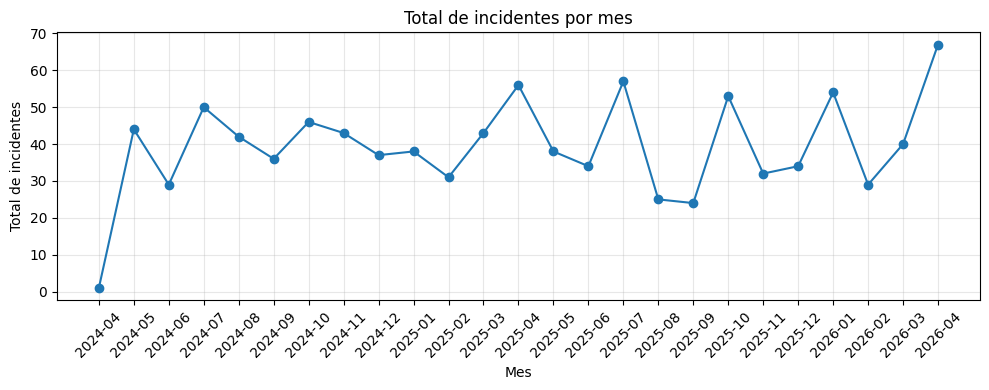

In [16]:
import matplotlib.pyplot as plt

# extrai ano-mes da data de operacao
df['ano_mes'] = df['data_operacao'].dt.to_period('M')

# agrega incidentes e operacoes por mes
incidentes_por_mes = df.groupby('ano_mes').agg(
    total_operacoes=('id_equipamento', 'count'),
    total_incidentes=('historico_incidentes', 'sum'),
    media_incidentes=('historico_incidentes', 'mean')
).round(2)

print("Incidentes por mes:")
print(incidentes_por_mes)

# mes com mais incidentes
mes_pico = incidentes_por_mes['total_incidentes'].idxmax()
print(f"\nMes com mais incidentes: {mes_pico} "
      f"({int(incidentes_por_mes.loc[mes_pico, 'total_incidentes'])} incidentes)")
print(f"Media de incidentes por mes: {incidentes_por_mes['total_incidentes'].mean():.1f}")

# grafico simples da evolucao temporal
plt.figure(figsize=(10, 4))
plt.plot(incidentes_por_mes.index.astype(str),
         incidentes_por_mes['total_incidentes'], marker='o')
plt.title('Total de incidentes por mes')
plt.xlabel('Mes')
plt.ylabel('Total de incidentes')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# normaliza temperatura e umidade para escala 0-1 (min-max)
df['temp_norm'] = (df['temperatura'] - df['temperatura'].min()) / (df['temperatura'].max() - df['temperatura'].min())
df['umid_norm'] = (df['umidade'] - df['umidade'].min()) / (df['umidade'].max() - df['umidade'].min())

# score ambiental (0-100): clima categorico + temperatura + umidade
df['score_ambiental'] = (
    (df['risco_ambiental'] / 5) * 0.50 +
    df['temp_norm'] * 0.25 +
    df['umid_norm'] * 0.25
) * 100

# score operacional (0-100): tipo de operacao + idade + historico
df['score_operacional'] = (
    (df['risco_operacional'] / 5) * 0.35 +
    (df['risco_idade'] / 4) * 0.20 +
    (df['risco_historico'] / 5) * 0.45
) * 100

# score final v2 (0-100): combina ambiental (40%) e operacional (60%)
df['score_risco_v2'] = (df['score_ambiental'] * 0.40 + df['score_operacional'] * 0.60).round(2)
df['score_ambiental'] = df['score_ambiental'].round(2)
df['score_operacional'] = df['score_operacional'].round(2)

# revisao das regras de classificacao (cortes pelos quartis do novo score)
def classificar_risco_v2(score):
    if score < 40:
        return 'Baixo'
    elif score < 60:
        return 'Médio'
    else:
        return 'Alto'

df['classificacao_risco_v2'] = df['score_risco_v2'].apply(classificar_risco_v2)

# resultados
print("Medias dos scores:")
print(f"  ambiental:   {df['score_ambiental'].mean():.1f}")
print(f"  operacional: {df['score_operacional'].mean():.1f}")
print(f"  final v2:    {df['score_risco_v2'].mean():.1f}")

print("\nNova classificacao (v2):")
print(df['classificacao_risco_v2'].value_counts())

# comparacao com a Sprint 1
print("\nComparacao com a Sprint 1:")
print("  correlacao score v1 x v2:", round(df['score_risco'].corr(df['score_risco_v2']), 3))
mudaram = (df['classificacao_risco'] != df['classificacao_risco_v2']).sum()
print(f"  equipamentos reclassificados: {mudaram} de {len(df)}")

print("\nMigracao de categorias (linhas=v1, colunas=v2):")
print(pd.crosstab(df['classificacao_risco'], df['classificacao_risco_v2']))

print("\nTop 5 equipamentos por score v2:")
print(df.sort_values('score_risco_v2', ascending=False)[
    ['id_equipamento', 'score_operacional', 'score_ambiental',
     'score_risco_v2', 'classificacao_risco_v2']].head(5).to_string(index=False))

Medias dos scores:
  ambiental:   51.1
  operacional: 53.5
  final v2:    52.6

Nova classificacao (v2):
classificacao_risco_v2
Médio    517
Alto     250
Baixo    133
Name: count, dtype: int64

Comparacao com a Sprint 1:
  correlacao score v1 x v2: 0.934
  equipamentos reclassificados: 150 de 900

Migracao de categorias (linhas=v1, colunas=v2):
classificacao_risco_v2  Alto  Baixo  Médio
classificacao_risco                       
Alto                     186      0     13
Baixo                      0    112     52
Médio                     64     21    452

Top 5 equipamentos por score v2:
id_equipamento  score_operacional  score_ambiental  score_risco_v2 classificacao_risco_v2
      EQP-1025              100.0            80.69           92.28                   Alto
      EQP-1740              100.0            74.68           89.87                   Alto
      EQP-1260              100.0            64.77           85.91                   Alto
      EQP-1177               95.0           

Perfis estrategicos identificados pelo K-Means:
         qtd  op_medio  amb_medio  score_medio             perfil
cluster                                                          
3        169      66.8       66.8         66.8            Crítico
2        198      72.6       41.7         60.2  Risco Operacional
0        219      39.1       66.8         50.2    Risco Ambiental
1        314      44.5       37.7         41.8        Baixo Risco

Quantidade de equipamentos por perfil:
perfil_estrategico
Baixo Risco          314
Risco Ambiental      219
Risco Operacional    198
Crítico              169
Name: count, dtype: int64


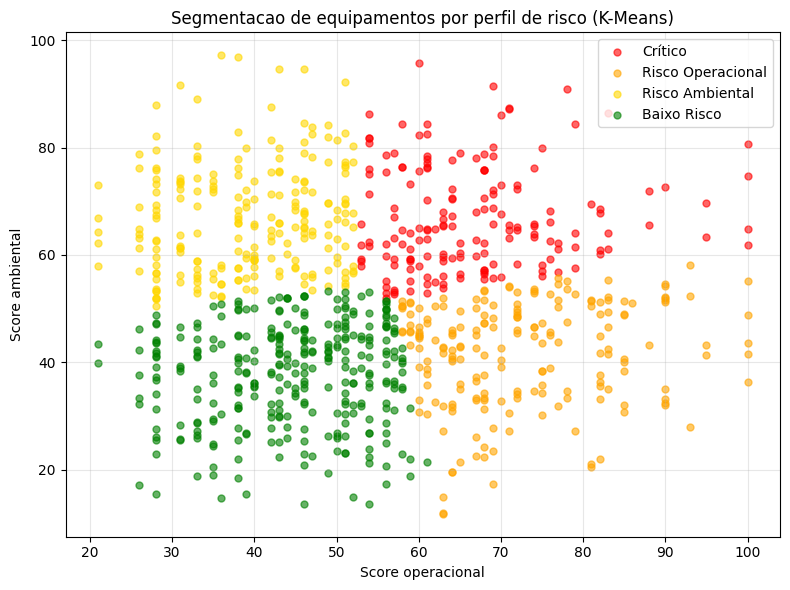

In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# usa as duas dimensoes de risco como features do agrupamento
features = df[['score_operacional', 'score_ambiental']]

# padroniza (K-Means e baseado em distancia)
scaler = StandardScaler()
X = scaler.fit_transform(features)

# agrupa em 4 perfis
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X)

# perfil medio de cada cluster
perfil_clusters = df.groupby('cluster').agg(
    qtd=('id_equipamento', 'count'),
    op_medio=('score_operacional', 'mean'),
    amb_medio=('score_ambiental', 'mean'),
    score_medio=('score_risco_v2', 'mean')
).round(1)

# nomeia cada cluster conforme o perfil (acima/abaixo da media de cada eixo)
media_op = df['score_operacional'].mean()
media_amb = df['score_ambiental'].mean()

def nomear_perfil(row):
    op_alto = row['op_medio'] >= media_op
    amb_alto = row['amb_medio'] >= media_amb
    if op_alto and amb_alto:
        return 'Crítico'
    elif op_alto and not amb_alto:
        return 'Risco Operacional'
    elif not op_alto and amb_alto:
        return 'Risco Ambiental'
    else:
        return 'Baixo Risco'

perfil_clusters['perfil'] = perfil_clusters.apply(nomear_perfil, axis=1)

# leva o nome do perfil de volta para o df
mapa_perfil = perfil_clusters['perfil'].to_dict()
df['perfil_estrategico'] = df['cluster'].map(mapa_perfil)

print("Perfis estrategicos identificados pelo K-Means:")
print(perfil_clusters.sort_values('score_medio', ascending=False))

print("\nQuantidade de equipamentos por perfil:")
print(df['perfil_estrategico'].value_counts())

# grafico: dispersao dos clusters
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
cores = {'Crítico': 'red', 'Risco Operacional': 'orange',
         'Risco Ambiental': 'gold', 'Baixo Risco': 'green'}
for perfil, cor in cores.items():
    sub = df[df['perfil_estrategico'] == perfil]
    plt.scatter(sub['score_operacional'], sub['score_ambiental'],
                label=perfil, alpha=0.6, s=25, color=cor)
plt.xlabel('Score operacional')
plt.ylabel('Score ambiental')
plt.title('Segmentacao de equipamentos por perfil de risco (K-Means)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# referencias de normalizacao (mesmas usadas no score v2)
temp_min, temp_max = df['temperatura'].min(), df['temperatura'].max()
umid_min, umid_max = df['umidade'].min(), df['umidade'].max()

# funcao reutilizavel: calcula os 3 scores a partir dos campos brutos
def calcular_scores(registro):
    risco_op = mapa_risco_operacional[registro['tipo_operacao']]
    risco_amb = mapa_risco_ambiental[registro['condicao_climatica']]
    r_idade = classificar_idade(registro['tempo_uso_anos'])
    r_hist = classificar_incidentes(registro['historico_incidentes'])
    temp_n = (registro['temperatura'] - temp_min) / (temp_max - temp_min)
    umid_n = (registro['umidade'] - umid_min) / (umid_max - umid_min)
    score_amb = ((risco_amb/5)*0.50 + temp_n*0.25 + umid_n*0.25) * 100
    score_op = ((risco_op/5)*0.35 + (r_idade/4)*0.20 + (r_hist/5)*0.45) * 100
    score_final = score_amb*0.40 + score_op*0.60
    return round(score_op, 2), round(score_amb, 2), round(score_final, 2)

# funcao de simulacao: aplica mudancas e compara antes/depois
def simular_cenario(id_equipamento, mudancas):
    registro = df[df['id_equipamento'] == id_equipamento].iloc[0].to_dict()
    op0, amb0, final0 = calcular_scores(registro)
    novo = registro.copy()
    novo.update(mudancas)
    op1, amb1, final1 = calcular_scores(novo)
    print(f"Simulacao para {id_equipamento}")
    print(f"  Mudancas aplicadas: {mudancas}")
    print(f"  Score operacional: {op0} -> {op1}")
    print(f"  Score ambiental:   {amb0} -> {amb1}")
    print(f"  Score final v2:    {final0} -> {final1}  ({final1-final0:+.2f})")
    print()
    return final1 - final0

# escolhe o equipamento de maior risco em proximidade de agua
alvo = df[df['tipo_operacao'] == 'Proximidade de água'].sort_values(
    'score_risco_v2', ascending=False).iloc[0]['id_equipamento']

print("=== Cenario 1: mudar de proximidade de agua para campo aberto ===")
simular_cenario(alvo, {'tipo_operacao': 'Campo aberto'})

print("=== Cenario 2: melhorar condicao climatica para Normal ===")
simular_cenario(alvo, {'condicao_climatica': 'Normal'})

print("=== Cenario 3: combinado (operacao + clima) ===")
simular_cenario(alvo, {'tipo_operacao': 'Campo aberto', 'condicao_climatica': 'Normal'})

# cenario em lote com apply + lambda
def score_se_mudasse(linha, nova_operacao):
    r = linha.to_dict()
    r['tipo_operacao'] = nova_operacao
    return calcular_scores(r)[2]

agua = df[df['tipo_operacao'] == 'Proximidade de água'].copy()
agua['score_simulado'] = agua.apply(lambda r: score_se_mudasse(r, 'Campo aberto'), axis=1)
reducao = (agua['score_risco_v2'] - agua['score_simulado']).mean()
print(f"Cenario em lote: {len(agua)} equipamentos em proximidade de agua")
print(f"Reducao media do score se mudassem para campo aberto: {reducao:.2f} pontos")

=== Cenario 1: mudar de proximidade de agua para campo aberto ===
Simulacao para EQP-1025
  Mudancas aplicadas: {'tipo_operacao': 'Campo aberto'}
  Score operacional: 100.0 -> 79.0
  Score ambiental:   80.69 -> 80.69
  Score final v2:    92.28 -> 79.68  (-12.60)

=== Cenario 2: melhorar condicao climatica para Normal ===
Simulacao para EQP-1025
  Mudancas aplicadas: {'condicao_climatica': 'Normal'}
  Score operacional: 100.0 -> 100.0
  Score ambiental:   80.69 -> 40.69
  Score final v2:    92.28 -> 76.28  (-16.00)

=== Cenario 3: combinado (operacao + clima) ===
Simulacao para EQP-1025
  Mudancas aplicadas: {'tipo_operacao': 'Campo aberto', 'condicao_climatica': 'Normal'}
  Score operacional: 100.0 -> 79.0
  Score ambiental:   80.69 -> 40.69
  Score final v2:    92.28 -> 63.68  (-28.60)

Cenario em lote: 138 equipamentos em proximidade de agua
Reducao media do score se mudassem para campo aberto: 12.60 pontos


In [20]:
def gerar_recomendacoes(linha):
    recs = []
    if linha['perfil_estrategico'] == 'Crítico':
        recs.append('Prioridade maxima: inspecao imediata e plano de mitigacao')
    if linha['tipo_operacao'] == 'Proximidade de água':
        recs.append('Reduzir exposicao a areas alagaveis / priorizar campo aberto')
    clima_adverso = linha['condicao_climatica'] in ['Tempestade', 'Chuvoso']
    if clima_adverso:
        recs.append('Ajustar janela de operacao para evitar clima adverso')
    elif linha['score_ambiental'] >= 65:
        recs.append('Monitorar temperatura e umidade (risco ambiental elevado)')
    if linha['historico_incidentes'] >= 3:
        recs.append('Programar manutencao preventiva (historico elevado)')
    if linha['tempo_uso_anos'] >= 15:
        recs.append('Avaliar renovacao do equipamento (vida util avancada)')
    if not recs:
        recs.append('Manter monitoramento de rotina')
    return recs

df['recomendacoes'] = df.apply(gerar_recomendacoes, axis=1)
df['qtd_recomendacoes'] = df['recomendacoes'].apply(len)

print("Recomendacoes mais frequentes na frota:")
print(df['recomendacoes'].explode().value_counts())

print("\nExemplos - 3 equipamentos do perfil Critico:")
criticos = df[df['perfil_estrategico'] == 'Crítico'].sort_values('score_risco_v2', ascending=False).head(3)
for _, l in criticos.iterrows():
    print(f"\n{l['id_equipamento']} | {l['tipo_operacao']} | {l['condicao_climatica']} | score {l['score_risco_v2']}")
    for r in l['recomendacoes']:
        print(f"   - {r}")

Recomendacoes mais frequentes na frota:
recomendacoes
Ajustar janela de operacao para evitar clima adverso            307
Manter monitoramento de rotina                                  287
Avaliar renovacao do equipamento (vida util avancada)           234
Prioridade maxima: inspecao imediata e plano de mitigacao       169
Programar manutencao preventiva (historico elevado)             139
Reduzir exposicao a areas alagaveis / priorizar campo aberto    138
Monitorar temperatura e umidade (risco ambiental elevado)        16
Name: count, dtype: int64

Exemplos - 3 equipamentos do perfil Critico:

EQP-1025 | Proximidade de água | Tempestade | score 92.28
   - Prioridade maxima: inspecao imediata e plano de mitigacao
   - Reduzir exposicao a areas alagaveis / priorizar campo aberto
   - Ajustar janela de operacao para evitar clima adverso
   - Programar manutencao preventiva (historico elevado)
   - Avaliar renovacao do equipamento (vida util avancada)

EQP-1740 | Proximidade de água | Ne

In [21]:
from sklearn.model_selection import train_test_split

# variaveis preditoras (X): caracteristicas brutas do equipamento
# alvo (y): a classificacao de risco
features_categoricas = ['tipo_equipamento', 'regiao', 'tipo_operacao', 'condicao_climatica']
features_numericas = ['temperatura', 'umidade', 'tempo_uso_anos', 'historico_incidentes']

# codifica as categoricas em colunas binarias (one-hot encoding)
X = pd.get_dummies(df[features_categoricas + features_numericas],
                   columns=features_categoricas)
y = df['classificacao_risco_v2']

print("Formato de X (preditoras):", X.shape)
print("Formato de y (alvo):", y.shape)
print("\nColunas preditoras apos codificacao:")
print(list(X.columns))

print("\nDistribuicao do alvo:")
print(y.value_counts())

# separa treino e teste (80/20, estratificado para manter a proporcao das classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print("\nTamanho do treino:", X_train.shape[0])
print("Tamanho do teste:", X_test.shape[0])
print("\nProporcao das classes no treino:")
print(y_train.value_counts(normalize=True).round(3))
print("\nProporcao das classes no teste:")
print(y_test.value_counts(normalize=True).round(3))

Formato de X (preditoras): (900, 24)
Formato de y (alvo): (900,)

Colunas preditoras apos codificacao:
['temperatura', 'umidade', 'tempo_uso_anos', 'historico_incidentes', 'tipo_equipamento_Colheitadeira', 'tipo_equipamento_Plantadeira', 'tipo_equipamento_Pulverizador', 'tipo_equipamento_Semeadora', 'tipo_equipamento_Trator', 'regiao_Centro-Oeste', 'regiao_Nordeste', 'regiao_Norte', 'regiao_Sudeste', 'regiao_Sul', 'tipo_operacao_Armazenamento', 'tipo_operacao_Campo aberto', 'tipo_operacao_Encosta', 'tipo_operacao_Proximidade de água', 'tipo_operacao_Transporte', 'condicao_climatica_Chuvoso', 'condicao_climatica_Neblina', 'condicao_climatica_Normal', 'condicao_climatica_Seco', 'condicao_climatica_Tempestade']

Distribuicao do alvo:
classificacao_risco_v2
Médio    517
Alto     250
Baixo    133
Name: count, dtype: int64

Tamanho do treino: 720
Tamanho do teste: 180

Proporcao das classes no treino:
classificacao_risco_v2
Médio    0.575
Alto     0.278
Baixo    0.147
Name: proportion, dtype

Acuracia no teste: 0.833 (83.3%)

Relatorio de classificacao:
              precision    recall  f1-score   support

        Alto       0.90      0.70      0.79        50
       Baixo       1.00      0.59      0.74        27
       Médio       0.79      0.96      0.87       103

    accuracy                           0.83       180
   macro avg       0.90      0.75      0.80       180
weighted avg       0.85      0.83      0.83       180

Matriz de confusao (linhas=real, colunas=previsto):
       Baixo  Médio  Alto
Baixo     16     11     0
Médio      0     99     4
Alto       0     15    35

Top 10 variaveis mais importantes para o modelo:
historico_incidentes                 0.230
umidade                              0.131
temperatura                          0.130
tempo_uso_anos                       0.118
condicao_climatica_Normal            0.037
tipo_operacao_Proximidade de água    0.035
condicao_climatica_Chuvoso           0.032
condicao_climatica_Seco              0.024
tipo_op

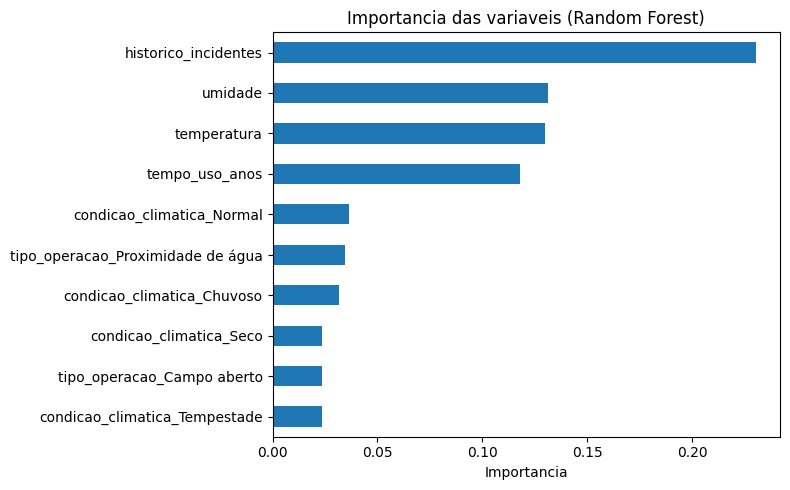

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# treina um Random Forest
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# previsoes no conjunto de teste (dados nunca vistos)
y_pred = modelo.predict(X_test)

# acuracia
acc = accuracy_score(y_test, y_pred)
print(f"Acuracia no teste: {acc:.3f} ({acc*100:.1f}%)")

print("\nRelatorio de classificacao:")
print(classification_report(y_test, y_pred))

print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=['Baixo','Médio','Alto']),
                   index=['Baixo','Médio','Alto'],
                   columns=['Baixo','Médio','Alto']))

# importancia das variaveis
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 variaveis mais importantes para o modelo:")
print(importancias.head(10).round(3))

# grafico das importancias
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
importancias.head(10).sort_values().plot(kind='barh')
plt.title('Importancia das variaveis (Random Forest)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [23]:
def relatorio_ranking_operacao_v2():
    """Ranking de risco por operacao usando o score refinado v2."""
    ranking = df.groupby('tipo_operacao').agg(
        score_v2_medio=('score_risco_v2', 'mean'),
        qtd=('id_equipamento', 'count'),
        pct_critico=('perfil_estrategico', lambda x: round((x == 'Crítico').mean()*100, 1))
    ).round(2).sort_values('score_v2_medio', ascending=False)
    print("RANKING DE RISCO POR OPERACAO (score v2):")
    print(ranking)

def relatorio_drivers_risco():
    """Principais fatores que influenciam o risco (segundo o modelo de IA)."""
    print("PRINCIPAIS DRIVERS DE RISCO (importancia no modelo):")
    print(importancias.head(5).round(3))

def relatorio_perfis():
    """Resumo dos perfis estrategicos identificados pelo K-Means."""
    print("PERFIS ESTRATEGICOS (K-Means):")
    resumo = df.groupby('perfil_estrategico').agg(
        qtd=('id_equipamento', 'count'),
        score_medio=('score_risco_v2', 'mean'),
        op_medio=('score_operacional', 'mean'),
        amb_medio=('score_ambiental', 'mean')
    ).round(1).sort_values('score_medio', ascending=False)
    print(resumo)

def relatorio_comparacao_cenarios(id_equipamento):
    """Compara cenarios de mitigacao para um equipamento."""
    print(f"COMPARACAO DE CENARIOS DE MITIGACAO - {id_equipamento}:")
    simular_cenario(id_equipamento, {'tipo_operacao': 'Campo aberto'})
    simular_cenario(id_equipamento, {'condicao_climatica': 'Normal'})
    simular_cenario(id_equipamento, {'tipo_operacao': 'Campo aberto', 'condicao_climatica': 'Normal'})

# testa os relatorios
relatorio_ranking_operacao_v2()
print()
relatorio_drivers_risco()
print()
relatorio_perfis()
print()
critico_top = df[df['perfil_estrategico']=='Crítico'].sort_values('score_risco_v2', ascending=False).iloc[0]['id_equipamento']
relatorio_comparacao_cenarios(critico_top)

RANKING DE RISCO POR OPERACAO (score v2):
                     score_v2_medio  qtd  pct_critico
tipo_operacao                                        
Proximidade de água           61.65  138         24.6
Encosta                       57.29  138         23.9
Transporte                    53.45  177         24.3
Campo aberto                  48.87  325         14.2
Armazenamento                 45.54  122         10.7

PRINCIPAIS DRIVERS DE RISCO (importancia no modelo):
historico_incidentes         0.230
umidade                      0.131
temperatura                  0.130
tempo_uso_anos               0.118
condicao_climatica_Normal    0.037
dtype: float64

PERFIS ESTRATEGICOS (K-Means):
                    qtd  score_medio  op_medio  amb_medio
perfil_estrategico                                       
Crítico             169         66.8      66.8       66.8
Risco Operacional   198         60.2      72.6       41.7
Risco Ambiental     219         50.2      39.1       66.8
Baixo Risco   

In [25]:
## Sprint 3 — MVP Funcional
##Integração das sprints anteriores em um protótipo funcional: o sistema recebe os dados de um equipamento, processa e devolve a análise de risco.

# ENTRADA - recebimento de dados externos (sensor/API simulada)
import json

def receber_dados_sensor(payload_json):
    try:
        return json.loads(payload_json)
    except json.JSONDecodeError:
        print("ERRO: payload JSON invalido.")
        return None

# payloads que chegariam de sensores diferentes
payload_1 = '''
{
    "id_equipamento": "SENSOR-001",
    "tipo_equipamento": "Colheitadeira",
    "regiao": "Centro-Oeste",
    "tipo_operacao": "Proximidade de água",
    "condicao_climatica": "Tempestade",
    "temperatura": 34.5,
    "umidade": 72.0,
    "tempo_uso_anos": 12,
    "historico_incidentes": 4
}
'''

payload_2 = '''
{
    "id_equipamento": "SENSOR-002",
    "tipo_equipamento": "Trator",
    "regiao": "Sul",
    "tipo_operacao": "Armazenamento",
    "condicao_climatica": "Normal",
    "temperatura": 22.0,
    "umidade": 45.0,
    "tempo_uso_anos": 3,
    "historico_incidentes": 0
}
'''

print("Recebendo dados do sensor...")
dados_recebidos = receber_dados_sensor(payload_1)

for chave, valor in dados_recebidos.items():
    print(f"  {chave}: {valor}")

Recebendo dados do sensor...
  id_equipamento: SENSOR-001
  tipo_equipamento: Colheitadeira
  regiao: Centro-Oeste
  tipo_operacao: Proximidade de água
  condicao_climatica: Tempestade
  temperatura: 34.5
  umidade: 72.0
  tempo_uso_anos: 12
  historico_incidentes: 4


In [26]:
# VALIDACAO - checagem dos dados recebidos antes do processamento

CAMPOS_OBRIGATORIOS = ['id_equipamento', 'tipo_equipamento', 'regiao',
                       'tipo_operacao', 'condicao_climatica', 'temperatura',
                       'umidade', 'tempo_uso_anos', 'historico_incidentes']

FAIXAS_VALIDAS = {
    'temperatura': (-5, 45),
    'umidade': (0, 100),
    'tempo_uso_anos': (0, 50),
    'historico_incidentes': (0, 20)
}

def validar_dados(dados):
    erros = []

    if dados is None:
        return False, ['Nenhum dado recebido']

    # campos obrigatorios
    for campo in CAMPOS_OBRIGATORIOS:
        if campo not in dados or dados[campo] is None:
            erros.append(f'Campo obrigatorio ausente: {campo}')

    if erros:
        return False, erros

    # categorias conhecidas pelo modelo
    if dados['tipo_operacao'] not in mapa_risco_operacional:
        erros.append(f"Tipo de operacao invalido: {dados['tipo_operacao']}")

    if dados['condicao_climatica'] not in mapa_risco_ambiental:
        erros.append(f"Condicao climatica invalida: {dados['condicao_climatica']}")

    # tipos e faixas numericas
    for campo, (minimo, maximo) in FAIXAS_VALIDAS.items():
        valor = dados[campo]
        if not isinstance(valor, (int, float)):
            erros.append(f'{campo} deve ser numerico (recebido: {type(valor).__name__})')
        elif valor < minimo or valor > maximo:
            erros.append(f'{campo} fora da faixa valida [{minimo}, {maximo}]: {valor}')

    return len(erros) == 0, erros


def tratar_inconsistencias(dados):
    tratado = dados.copy()
    for campo in ['tipo_equipamento', 'regiao']:
        if isinstance(tratado.get(campo), str):
            tratado[campo] = tratado[campo].strip().title()
    if isinstance(tratado.get('id_equipamento'), str):
        tratado['id_equipamento'] = tratado['id_equipamento'].strip().upper()
    return tratado


# testa a validacao com os payloads recebidos
for nome, payload in [('payload_1', payload_1), ('payload_2', payload_2)]:
    dados = receber_dados_sensor(payload)
    valido, erros = validar_dados(dados)
    print(f"{nome}: valido={valido}")
    for e in erros:
        print(f"   - {e}")

# payload com problemas, para demonstrar a validacao rejeitando
payload_ruim = '''
{
    "id_equipamento": "SENSOR-999",
    "tipo_equipamento": "Trator",
    "regiao": "Sul",
    "tipo_operacao": "Voando",
    "condicao_climatica": "Seco",
    "temperatura": 85.0,
    "umidade": 150.0,
    "tempo_uso_anos": 5,
    "historico_incidentes": 1
}
'''

print("\npayload_ruim:")
dados_ruins = receber_dados_sensor(payload_ruim)
valido, erros = validar_dados(dados_ruins)
print(f"  valido={valido}")
for e in erros:
    print(f"   - {e}")

payload_1: valido=True
payload_2: valido=True

payload_ruim:
  valido=False
   - Tipo de operacao invalido: Voando
   - temperatura fora da faixa valida [-5, 45]: 85.0
   - umidade fora da faixa valida [0, 100]: 150.0


In [27]:
# PROCESSAMENTO - motor de risco: conecta os dados recebidos ao modelo das sprints anteriores

def classificar_nivel_risco(score):
    if score < 40:
        return 'Baixo'
    elif score < 60:
        return 'Médio'
    else:
        return 'Alto'


def identificar_perfil(score_op, score_amb):
    op_alto = score_op >= 55
    amb_alto = score_amb >= 55
    if op_alto and amb_alto:
        return 'Crítico'
    elif op_alto:
        return 'Risco Operacional'
    elif amb_alto:
        return 'Risco Ambiental'
    else:
        return 'Baixo Risco'


def processar_equipamento(payload_json):
    dados = receber_dados_sensor(payload_json)
    valido, erros = validar_dados(dados)

    if not valido:
        return {'status': 'rejeitado', 'erros': erros}

    dados = tratar_inconsistencias(dados)
    score_op, score_amb, score_final = calcular_scores(dados)
    classificacao = classificar_nivel_risco(score_final)
    perfil = identificar_perfil(score_op, score_amb)

    # monta o registro completo para alimentar alertas e recomendacoes
    registro = dados.copy()
    registro['score_operacional'] = score_op
    registro['score_ambiental'] = score_amb
    registro['score_risco_v2'] = score_final
    registro['classificacao_risco_v2'] = classificacao
    registro['perfil_estrategico'] = perfil

    alertas = gerar_alertas({**registro, 'classificacao_risco': classificacao})
    recomendacoes = gerar_recomendacoes(registro)

    return {
        'status': 'processado',
        'id_equipamento': dados['id_equipamento'],
        'score_operacional': score_op,
        'score_ambiental': score_amb,
        'score_risco': score_final,
        'classificacao': classificacao,
        'perfil': perfil,
        'alertas': alertas,
        'recomendacoes': recomendacoes,
        'dados_entrada': dados
    }


# testa o pipeline completo
resultado_1 = processar_equipamento(payload_1)
print("payload_1:", resultado_1['status'])
print(f"  {resultado_1['id_equipamento']} | score {resultado_1['score_risco']} "
      f"({resultado_1['classificacao']}) | perfil {resultado_1['perfil']}")

resultado_2 = processar_equipamento(payload_2)
print("\npayload_2:", resultado_2['status'])
print(f"  {resultado_2['id_equipamento']} | score {resultado_2['score_risco']} "
      f"({resultado_2['classificacao']}) | perfil {resultado_2['perfil']}")

resultado_ruim = processar_equipamento(payload_ruim)
print("\npayload_ruim:", resultado_ruim['status'])
for e in resultado_ruim['erros']:
    print(f"   - {e}")

payload_1: processado
  SENSOR-001 | score 91.79 (Alto) | perfil Crítico

payload_2: processado
  SENSOR-002 | score 22.76 (Baixo) | perfil Baixo Risco

payload_ruim: rejeitado
   - Tipo de operacao invalido: Voando
   - temperatura fora da faixa valida [-5, 45]: 85.0
   - umidade fora da faixa valida [0, 100]: 150.0


In [28]:
# SAIDA - apresentacao dos resultados de forma interpretavel

def interpretar_risco(classificacao):
    mensagens = {
        'Baixo': 'Equipamento em condicao segura. Manter rotina normal de operacao.',
        'Médio': 'Atencao: fatores de risco identificados. Acompanhar de perto.',
        'Alto': 'ALERTA: risco elevado. Acao preventiva recomendada com urgencia.'
    }
    return mensagens.get(classificacao, 'Classificacao desconhecida.')


def exibir_resultado(resultado):
    print("=" * 58)

    if resultado['status'] == 'rejeitado':
        print("ANALISE NAO REALIZADA - dados invalidos")
        print("=" * 58)
        for e in resultado['erros']:
            print(f"  [X] {e}")
        print("\nCorrija os dados e envie novamente.")
        return

    d = resultado['dados_entrada']
    print(f"ANALISE DE RISCO - {resultado['id_equipamento']}")
    print("=" * 58)
    print(f"{d['tipo_equipamento']} | {d['regiao']} | {d['tipo_operacao']}")
    print(f"Clima: {d['condicao_climatica']} | {d['temperatura']}C | {d['umidade']}% umidade")
    print(f"Uso: {d['tempo_uso_anos']} anos | Incidentes: {d['historico_incidentes']}")
    print("-" * 58)
    print(f"Score operacional : {resultado['score_operacional']:>6}")
    print(f"Score ambiental   : {resultado['score_ambiental']:>6}")
    print(f"SCORE DE RISCO    : {resultado['score_risco']:>6}  [{resultado['classificacao'].upper()}]")
    print(f"Perfil            : {resultado['perfil']}")
    print("-" * 58)
    print(interpretar_risco(resultado['classificacao']))

    if resultado['alertas']:
        print(f"\nALERTAS ({len(resultado['alertas'])}):")
        for a in resultado['alertas']:
            print(f"  [!] {a}")
    else:
        print("\nNenhum alerta ativo.")

    print(f"\nRECOMENDACOES ({len(resultado['recomendacoes'])}):")
    for r in resultado['recomendacoes']:
        print(f"  -> {r}")
    print("=" * 58)


# exibe os resultados processados
exibir_resultado(resultado_1)
print()
exibir_resultado(resultado_2)
print()
exibir_resultado(resultado_ruim)

ANALISE DE RISCO - SENSOR-001
Colheitadeira | Centro-Oeste | Proximidade de água
Clima: Tempestade | 34.5C | 72.0% umidade
Uso: 12 anos | Incidentes: 4
----------------------------------------------------------
Score operacional :   95.0
Score ambiental   :  86.98
SCORE DE RISCO    :  91.79  [ALTO]
Perfil            : Crítico
----------------------------------------------------------
ALERTA: risco elevado. Acao preventiva recomendada com urgencia.

ALERTAS (4):
  [!] Risco elevado por operação próxima à água
  [!] Condição climática adversa: Tempestade
  [!] Histórico crítico: 4 incidentes
  [!] Classificação geral: ALTO RISCO

RECOMENDACOES (4):
  -> Prioridade maxima: inspecao imediata e plano de mitigacao
  -> Reduzir exposicao a areas alagaveis / priorizar campo aberto
  -> Ajustar janela de operacao para evitar clima adverso
  -> Programar manutencao preventiva (historico elevado)

ANALISE DE RISCO - SENSOR-002
Trator | Sul | Armazenamento
Clima: Normal | 22.0C | 45.0% umidade
Uso

In [29]:
# VALIDACAO FUNCIONAL - teste do fluxo completo com multiplos cenarios

lote_sensores = [
    '{"id_equipamento":"SENSOR-001","tipo_equipamento":"Colheitadeira","regiao":"Centro-Oeste","tipo_operacao":"Proximidade de água","condicao_climatica":"Tempestade","temperatura":34.5,"umidade":72.0,"tempo_uso_anos":12,"historico_incidentes":4}',
    '{"id_equipamento":"SENSOR-002","tipo_equipamento":"Trator","regiao":"Sul","tipo_operacao":"Armazenamento","condicao_climatica":"Normal","temperatura":22.0,"umidade":45.0,"tempo_uso_anos":3,"historico_incidentes":0}',
    '{"id_equipamento":"SENSOR-003","tipo_equipamento":"Pulverizador","regiao":"Nordeste","tipo_operacao":"Transporte","condicao_climatica":"Chuvoso","temperatura":28.0,"umidade":80.0,"tempo_uso_anos":8,"historico_incidentes":2}',
    '{"id_equipamento":"SENSOR-004","tipo_equipamento":"Plantadeira","regiao":"Norte","tipo_operacao":"Encosta","condicao_climatica":"Neblina","temperatura":19.0,"umidade":88.0,"tempo_uso_anos":17,"historico_incidentes":3}',
    '{"id_equipamento":"SENSOR-005","tipo_equipamento":"Semeadora","regiao":"Sudeste","tipo_operacao":"Campo aberto","condicao_climatica":"Seco","temperatura":31.0,"umidade":35.0,"tempo_uso_anos":6,"historico_incidentes":1}',
    '{"id_equipamento":"SENSOR-006","tipo_equipamento":"Trator","regiao":"Sul","tipo_operacao":"Voando","condicao_climatica":"Seco","temperatura":85.0,"umidade":150.0,"tempo_uso_anos":5,"historico_incidentes":1}',
    '{"id_equipamento":"SENSOR-007","tipo_equipamento":"Trator","regiao":"Sul","tipo_operacao":"Campo aberto","temperatura":25.0,"umidade":50.0,"tempo_uso_anos":5,"historico_incidentes":1}',
    '{"quebrado": ',
]


def processar_lote(lista_payloads):
    processados = []
    rejeitados = []
    for p in lista_payloads:
        r = processar_equipamento(p)
        if r['status'] == 'processado':
            processados.append(r)
        else:
            rejeitados.append(r)
    return processados, rejeitados


processados, rejeitados = processar_lote(lote_sensores)

print(f"Total recebido: {len(lote_sensores)}")
print(f"Processados com sucesso: {len(processados)}")
print(f"Rejeitados na validacao: {len(rejeitados)}")

print("\nResumo dos processados:")
for r in processados:
    print(f"  {r['id_equipamento']}: score {r['score_risco']:>6} | "
          f"{r['classificacao']:<6} | {r['perfil']}")

print("\nMotivos das rejeicoes:")
for r in rejeitados:
    print(f"  {r['erros']}")

ERRO: payload JSON invalido.
Total recebido: 8
Processados com sucesso: 5
Rejeitados na validacao: 3

Resumo dos processados:
  SENSOR-001: score  91.79 | Alto   | Crítico
  SENSOR-002: score  22.76 | Baixo  | Baixo Risco
  SENSOR-003: score  64.05 | Alto   | Crítico
  SENSOR-004: score  78.51 | Alto   | Crítico
  SENSOR-005: score  47.03 | Médio  | Baixo Risco

Motivos das rejeicoes:
  ['Tipo de operacao invalido: Voando', 'temperatura fora da faixa valida [-5, 45]: 85.0', 'umidade fora da faixa valida [0, 100]: 150.0']
  ['Campo obrigatorio ausente: condicao_climatica']
  ['Nenhum dado recebido']


PAINEL DE RESULTADOS PROCESSADOS
        id   equipamento            operacao  score classificacao  qtd_alertas
SENSOR-001 Colheitadeira Proximidade de água  91.79          Alto            4
SENSOR-002        Trator       Armazenamento  22.76         Baixo            0
SENSOR-003  Pulverizador          Transporte  64.05          Alto            2
SENSOR-004   Plantadeira             Encosta  78.51          Alto            3
SENSOR-005     Semeadora        Campo aberto  47.03         Médio            0

RESUMO DA EXECUCAO
  Recebidos: 8
  Processados: 5 | Rejeitados: 3
  Score medio: 60.83
  Score maximo: 91.79 (SENSOR-001)
  Total de alertas emitidos: 9

DISTRIBUICAO POR CLASSIFICACAO
classificacao
Alto     3
Baixo    1
Médio    1

EQUIPAMENTOS QUE EXIGEM ATENCAO (Alto risco)
        id            operacao      clima  score  qtd_alertas
SENSOR-001 Proximidade de água Tempestade  91.79            4
SENSOR-004             Encosta    Neblina  78.51            3
SENSOR-003          Transpo

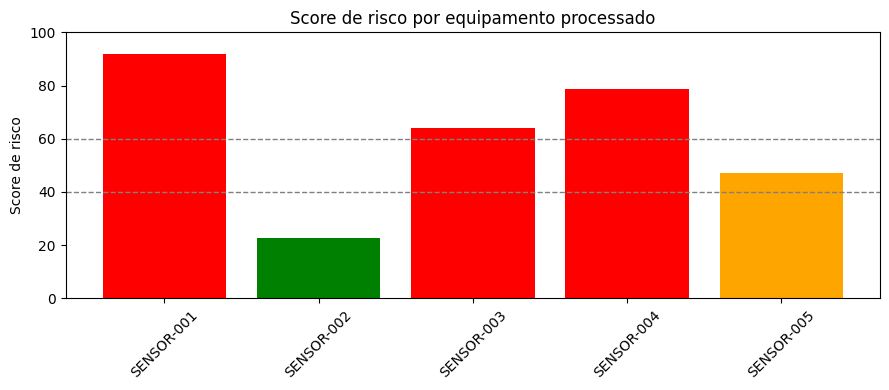

In [30]:
# DASHBOARD - consolidacao dos resultados em tabelas e visualizacao
import matplotlib.pyplot as plt

def montar_tabela_resultados(processados):
    linhas = []
    for r in processados:
        d = r['dados_entrada']
        linhas.append({
            'id': r['id_equipamento'],
            'equipamento': d['tipo_equipamento'],
            'regiao': d['regiao'],
            'operacao': d['tipo_operacao'],
            'clima': d['condicao_climatica'],
            'score_op': r['score_operacional'],
            'score_amb': r['score_ambiental'],
            'score': r['score_risco'],
            'classificacao': r['classificacao'],
            'perfil': r['perfil'],
            'qtd_alertas': len(r['alertas'])
        })
    return pd.DataFrame(linhas)


def dashboard(processados, rejeitados):
    painel = montar_tabela_resultados(processados)

    print("PAINEL DE RESULTADOS PROCESSADOS")
    print(painel[['id', 'equipamento', 'operacao', 'score',
                  'classificacao', 'qtd_alertas']].to_string(index=False))

    print("\nRESUMO DA EXECUCAO")
    print(f"  Recebidos: {len(processados) + len(rejeitados)}")
    print(f"  Processados: {len(processados)} | Rejeitados: {len(rejeitados)}")
    print(f"  Score medio: {painel['score'].mean():.2f}")
    print(f"  Score maximo: {painel['score'].max()} ({painel.loc[painel['score'].idxmax(), 'id']})")
    print(f"  Total de alertas emitidos: {painel['qtd_alertas'].sum()}")

    print("\nDISTRIBUICAO POR CLASSIFICACAO")
    print(painel['classificacao'].value_counts().to_string())

    print("\nEQUIPAMENTOS QUE EXIGEM ATENCAO (Alto risco)")
    criticos = painel[painel['classificacao'] == 'Alto'].sort_values('score', ascending=False)
    if criticos.empty:
        print("  Nenhum equipamento em alto risco.")
    else:
        print(criticos[['id', 'operacao', 'clima', 'score', 'qtd_alertas']].to_string(index=False))

    # grafico: score por equipamento, colorido pela classificacao
    cores_map = {'Baixo': 'green', 'Médio': 'orange', 'Alto': 'red'}
    cores = painel['classificacao'].map(cores_map)

    plt.figure(figsize=(9, 4))
    plt.bar(painel['id'], painel['score'], color=cores)
    plt.axhline(40, color='gray', linestyle='--', linewidth=1)
    plt.axhline(60, color='gray', linestyle='--', linewidth=1)
    plt.title('Score de risco por equipamento processado')
    plt.ylabel('Score de risco')
    plt.xticks(rotation=45)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

    return painel


painel = dashboard(processados, rejeitados)

In [31]:
# MENU INTEGRADO - interface unica do sistema (Sprints 1, 2 e 3)

def analisar_novo_equipamento():
    print("\nInforme os dados do equipamento:")
    try:
        dados = {
            'id_equipamento': input("  ID: ").strip().upper(),
            'tipo_equipamento': input("  Tipo (Trator/Colheitadeira/Pulverizador/Plantadeira/Semeadora): ").strip(),
            'regiao': input("  Regiao (Sul/Sudeste/Centro-Oeste/Nordeste/Norte): ").strip(),
            'tipo_operacao': input("  Operacao (Campo aberto/Transporte/Proximidade de água/Encosta/Armazenamento): ").strip(),
            'condicao_climatica': input("  Clima (Seco/Chuvoso/Tempestade/Neblina/Normal): ").strip(),
            'temperatura': float(input("  Temperatura (C): ")),
            'umidade': float(input("  Umidade (%): ")),
            'tempo_uso_anos': int(input("  Tempo de uso (anos): ")),
            'historico_incidentes': int(input("  Historico de incidentes: "))
        }
    except ValueError:
        print("\nValor numerico invalido. Operacao cancelada.")
        return
    exibir_resultado(processar_equipamento(json.dumps(dados)))


def buscar_equipamento_base():
    id_busca = input("Digite o ID do equipamento (ex: EQP-1050): ").strip().upper()
    resultado = df[df['id_equipamento'] == id_busca]
    if resultado.empty:
        print(f"\nEquipamento '{id_busca}' nao encontrado.")
        return
    l = resultado.iloc[0]
    print("\n" + "=" * 58)
    print(f"DETALHES DO EQUIPAMENTO {l['id_equipamento']}")
    print("=" * 58)
    print(f"Tipo: {l['tipo_equipamento']} | Regiao: {l['regiao']}")
    print(f"Operacao: {l['tipo_operacao']} | Clima: {l['condicao_climatica']}")
    print(f"Score operacional: {l['score_operacional']} | ambiental: {l['score_ambiental']}")
    print(f"Score final: {l['score_risco_v2']} ({l['classificacao_risco_v2']})")
    print(f"Perfil estrategico: {l['perfil_estrategico']}")
    print("\nRecomendacoes:")
    for r in l['recomendacoes']:
        print(f"   - {r}")


def exibir_menu_final():
    print("\n" + "=" * 58)
    print("SISTEMA DE ANALISE DE RISCO - SOMPO SEGURADORA")
    print("Equipamentos Agricolas - MVP")
    print("=" * 58)
    print("--- MVP: entrada de dados e processamento ---")
    print("1 - Processar lote de sensores")
    print("2 - Dashboard dos resultados")
    print("3 - Analisar novo equipamento (entrada manual)")
    print("4 - Detalhar equipamento processado")
    print("--- Analises da base historica ---")
    print("5 - Ranking de risco por operacao")
    print("6 - Perfis estrategicos (K-Means)")
    print("7 - Principais drivers de risco")
    print("8 - Buscar equipamento na base")
    print("9 - Comparar cenarios de mitigacao")
    print("0 - Sair")
    print("=" * 58)


def executar_sistema():
    global processados, rejeitados
    while True:
        exibir_menu_final()
        opcao = input("Escolha uma opcao: ").strip()

        if opcao == '1':
            processados, rejeitados = processar_lote(lote_sensores)
            print(f"\n{len(processados)} processados | {len(rejeitados)} rejeitados")
        elif opcao == '2':
            dashboard(processados, rejeitados)
        elif opcao == '3':
            analisar_novo_equipamento()
        elif opcao == '4':
            idb = input("ID do sensor (ex: SENSOR-001): ").strip().upper()
            achou = [r for r in processados if r['id_equipamento'] == idb]
            if achou:
                exibir_resultado(achou[0])
            else:
                print("Sensor nao encontrado no lote processado.")
        elif opcao == '5':
            relatorio_ranking_operacao_v2()
        elif opcao == '6':
            relatorio_perfis()
        elif opcao == '7':
            relatorio_drivers_risco()
        elif opcao == '8':
            buscar_equipamento_base()
        elif opcao == '9':
            idq = input("ID do equipamento (ex: EQP-1025): ").strip().upper()
            if (df['id_equipamento'] == idq).any():
                relatorio_comparacao_cenarios(idq)
            else:
                print("Equipamento nao encontrado.")
        elif opcao == '0':
            print("\nEncerrando o sistema. Ate logo!")
            break
        else:
            print("\nOpcao invalida.")
        input("\nPressione ENTER para continuar...")


executar_sistema()


SISTEMA DE ANALISE DE RISCO - SOMPO SEGURADORA
Equipamentos Agricolas - MVP
--- MVP: entrada de dados e processamento ---
1 - Processar lote de sensores
2 - Dashboard dos resultados
3 - Analisar novo equipamento (entrada manual)
4 - Detalhar equipamento processado
--- Analises da base historica ---
5 - Ranking de risco por operacao
6 - Perfis estrategicos (K-Means)
7 - Principais drivers de risco
8 - Buscar equipamento na base
9 - Comparar cenarios de mitigacao
0 - Sair
Escolha uma opcao: 9
ID do equipamento (ex: EQP-1025): eqp-1025
COMPARACAO DE CENARIOS DE MITIGACAO - EQP-1025:
Simulacao para EQP-1025
  Mudancas aplicadas: {'tipo_operacao': 'Campo aberto'}
  Score operacional: 100.0 -> 79.0
  Score ambiental:   80.69 -> 80.69
  Score final v2:    92.28 -> 79.68  (-12.60)

Simulacao para EQP-1025
  Mudancas aplicadas: {'condicao_climatica': 'Normal'}
  Score operacional: 100.0 -> 100.0
  Score ambiental:   80.69 -> 40.69
  Score final v2:    92.28 -> 76.28  (-16.00)

Simulacao para E